<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Autoencoder Intuition</b>
</h1>
<div style="font-family:'Times New Roman';">
An autoencoder squeezes the input down into a small code and then tries to rebuild the original from that code. There is no label, the target is the input itself, so its unsupervised. The FCN in the last folder already had this encoder decoder shape, here the point is not segmentation but compression.
</div>

## the idea

two halves joined in the middle:

- **encoder** : input goes down to a small vector (the bottleneck / code)
- **decoder** : that small vector goes back up to the original size

the bottleneck is the whole trick. if the code is smaller than the input, the network cannot just copy, it has to throw away the useless stuff and keep whatever is needed to rebuild the image.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

digits = load_digits()
X = digits.data / 16.0     # 8x8 images flattened to 64, scaled to 0..1
y = digits.target
print(X.shape, X.min(), X.max())

(1797, 64) 0.0 1.0


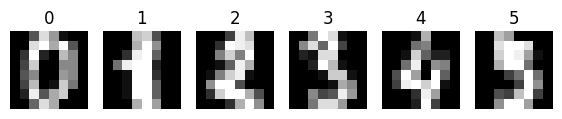

In [3]:
plt.figure(figsize=(7,2))
for i in range(6):
    plt.subplot(1,6,i+1)
    plt.imshow(X[i].reshape(8,8), cmap='gray')
    plt.title(y[i])
    plt.axis('off')
plt.show()

## PCA is a linear autoencoder

before writing any network, PCA does exactly the same job in the linear case. `fit_transform` is the encoder (64 numbers down to k) and `inverse_transform` is the decoder (k back up to 64). so it is the simplest autoencoder possible.

In [4]:
pca = PCA(n_components=16)
code16 = pca.fit_transform(X)       # encoder
rebuilt = pca.inverse_transform(code16)   # decoder

print("input :", X.shape)
print("code  :", code16.shape)
print("rebuilt back to :", rebuilt.shape)

input : (1797, 64)
code  : (1797, 16)
rebuilt back to : (1797, 64)


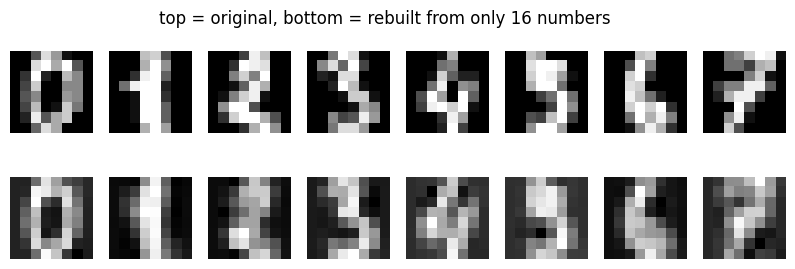

In [5]:
fig, ax = plt.subplots(2, 8, figsize=(10,3))
for i in range(8):
    ax[0,i].imshow(X[i].reshape(8,8), cmap='gray'); ax[0,i].axis('off')
    ax[1,i].imshow(rebuilt[i].reshape(8,8), cmap='gray'); ax[1,i].axis('off')
ax[0,0].set_ylabel('original'); ax[1,0].set_ylabel('rebuilt')
plt.suptitle('top = original, bottom = rebuilt from only 16 numbers')
plt.show()

64 pixels went down to 16 numbers and the digit is still readable. thats compression, and its lossy, look at the blurry edges.

## how small can the code get

running the same thing for diffrent bottleneck sizes and checking the reconstruction error.

In [6]:
sizes = [2, 4, 8, 16, 32, 64]
errors = []

for k in sizes:
    p = PCA(n_components=k)
    r = p.inverse_transform(p.fit_transform(X))
    mse = ((X - r) ** 2).mean()
    errors.append(mse)
    print("code size", str(k).rjust(2), " mse", round(mse, 5))

code size  2  mse 0.05243
code size  4  mse 0.03761
code size  8  mse 0.02391
code size 16  mse 0.01104
code size 32  mse 0.00247
code size 64  mse 0.0


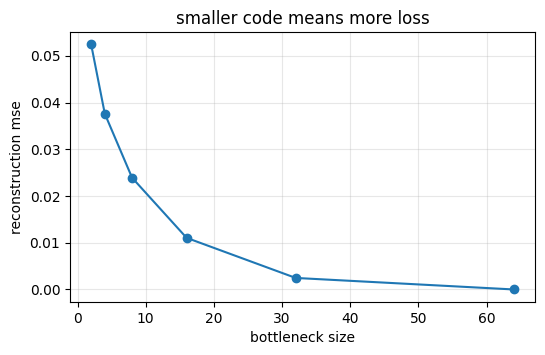

In [7]:
plt.figure(figsize=(6,3.5))
plt.plot(sizes, errors, 'o-')
plt.xlabel('bottleneck size'); plt.ylabel('reconstruction mse')
plt.title('smaller code means more loss')
plt.grid(alpha=.3)
plt.show()

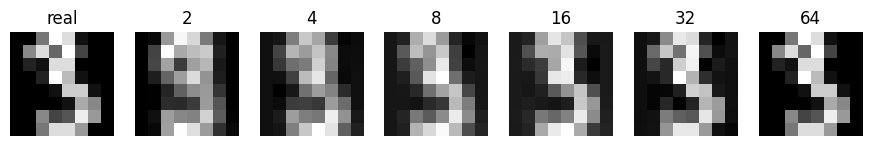

In [8]:
fig, ax = plt.subplots(1, len(sizes)+1, figsize=(11,2))
ax[0].imshow(X[3].reshape(8,8), cmap='gray'); ax[0].set_title('real'); ax[0].axis('off')
for j, k in enumerate(sizes):
    p = PCA(n_components=k)
    r = p.inverse_transform(p.fit_transform(X))
    ax[j+1].imshow(r[3].reshape(8,8), cmap='gray')
    ax[j+1].set_title(k); ax[j+1].axis('off')
plt.show()

at code size 2 its barely a digit, by 16 its almost perfect. so the useful information in a 64 pixel digit is way less than 64 numbers.

## what the code actually holds

if the bottleneck is 2 we can plot it. same digits land in the same area, wich means the code is carrying the shape information and not just random numbers.

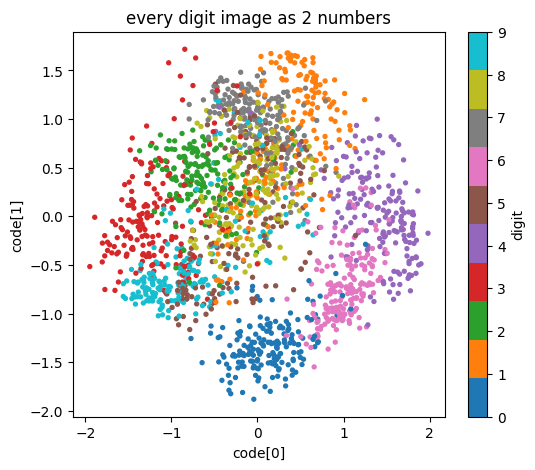

In [9]:
code2 = PCA(n_components=2).fit_transform(X)

plt.figure(figsize=(6,5))
sc = plt.scatter(code2[:,0], code2[:,1], c=y, cmap='tab10', s=8)
plt.colorbar(sc, label='digit')
plt.xlabel('code[0]'); plt.ylabel('code[1]')
plt.title('every digit image as 2 numbers')
plt.show()

## why bother with a neural autoencoder then

PCA can only do straight line (linear) compression. a neural autoencoder puts activation functions in between so the encoder can bend, wich fits data that is not linear. thats what i am writing by hand in the next notebook.

| | PCA | neural autoencoder |
|---|---|---|
| mapping | linear only | non linear |
| training | one shot, closed form | gradient descent, epochs |
| speed | very fast | slow |
| output | fixed | depends on architecture |

### quick recap
autoencoder = encoder + bottleneck + decoder, trained to output its own input. PCA is the linear version of it and already works surprisingly well on these digits.